# Hospital Readmission Lagged Pipeline — Exploratory Data Analysis

**Scope note:** per the assignment, this is *pre-cleaning* EDA. No imputation, no
near-zero-variance filtering, no encoding, no outlier handling, and no Box-Cox transform
are applied anywhere in this notebook — only the joins/pivots needed to get the six raw
CMS source files into one hospital-per-row table, which the assignment explicitly allows.

The first code cell locates the repository root automatically, so this notebook runs
correctly whether opened directly in Jupyter or executed via `nbconvert`/`papermill`
from any working directory, e.g.:
`uv run --with jupyter,nbconvert,ipykernel,seaborn,pyarrow jupyter nbconvert --to notebook --execute --inplace notebooks/hospital_readmission_lagged_EDA.ipynb`


## 1. Build the raw, pre-cleaning analysis dataset

Six 2024 predictor files (long-format pivoted to wide, or already-wide direct-joined) plus the 2025 target file, joined on `Facility ID`. No missing-value handling of any kind happens in this section.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)

def find_repo_root(start: Path) -> Path:
    """Walk upward from `start` until a pyproject.toml is found. Makes this notebook
    runnable regardless of the working directory Jupyter/nbconvert launches it from."""
    p = start.resolve()
    while not (p / "pyproject.toml").exists():
        if p.parent == p:
            raise RuntimeError("Could not locate repo root (no pyproject.toml found above " + str(start) + ")")
        p = p.parent
    return p

REPO_ROOT = find_repo_root(Path.cwd())
SRC_2024 = REPO_ROOT / "data/source_data/hospitial_readmission_lagged/hospitals_annual_2024/hospitals_2024-10-30"
SRC_2025 = REPO_ROOT / "data/source_data/hospitial_readmission_lagged/hospitals_annual_2025/hospitals_2025-11-26"

def fid(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize Facility ID to a join-able numeric key; every other value is left untouched."""
    df = df.copy()
    df["Facility ID"] = pd.to_numeric(df["Facility ID"], errors="coerce")
    return df

In [2]:
# --- Target: 2025 HRRP, pneumonia measure ---
hrrp = fid(pd.read_csv(SRC_2025 / "FY_2025_Hospital_Readmissions_Reduction_Program_Hospital.csv"))
pn = hrrp[hrrp["Measure Name"] == "READM-30-PN-HRRP"][
    ["Facility ID", "State", "Number of Discharges", "Excess Readmission Ratio"]
].rename(columns={"Excess Readmission Ratio": "excess_readmission_ratio_pn_2025"})
print(f"PN rows in 2025 HRRP file: {len(pn)}")
pn.head()

PN rows in 2025 HRRP file: 3085


,Facility ID,State,Number of Discharges,excess_readmission_ratio_pn_2025
4,10001,AL,490.0,0.9715
9,10005,AL,305.0,0.8495
16,10006,AL,621.0,1.0112
21,10007,AL,85.0,1.0488
28,10008,AL,NaN,NaN


In [3]:
# --- HCAHPS: pivot the 5 composite/summary questions named in the proposal ---
hcahps = fid(pd.read_csv(SRC_2024 / "HCAHPS-Hospital.csv"))
keep_questions = {
    "Nurse communication - linear mean score": "hcahps_nurse_comm",
    "Doctor communication - linear mean score": "hcahps_doctor_comm",
    "Discharge information - linear mean score": "hcahps_discharge_info",
    "Care transition - linear mean score": "hcahps_care_transition",
    "Overall hospital rating - linear mean score": "hcahps_overall_rating",
}
hc = hcahps[hcahps["HCAHPS Question"].isin(keep_questions)].copy()
hc["HCAHPS Linear Mean Value"] = pd.to_numeric(hc["HCAHPS Linear Mean Value"], errors="coerce")
hc_wide = hc.pivot_table(index="Facility ID", columns="HCAHPS Question", values="HCAHPS Linear Mean Value", aggfunc="first")
hc_wide = hc_wide.rename(columns=keep_questions).reset_index()
hc_wide.head()

/var/folders/xt/m7wppd_s38jcxpc_kbdg8s640000gn/T/ipykernel_36865/1280436161.py:2: DtypeWarning: Columns (12,14,17,19) have mixed types. Specify dtype option on import or set low_memory=False.
  hcahps = fid(pd.read_csv(SRC_2024 / "HCAHPS-Hospital.csv"))


HCAHPS Question,Facility ID,hcahps_care_transition,hcahps_discharge_info,hcahps_doctor_comm,hcahps_nurse_comm,hcahps_overall_rating
0,10001.0,82.0,86.0,91.0,89.0,89.0
1,10005.0,81.0,87.0,92.0,91.0,87.0
2,10006.0,76.0,83.0,88.0,88.0,82.0
3,10007.0,82.0,94.0,95.0,94.0,91.0
4,10011.0,80.0,87.0,91.0,91.0,87.0


In [4]:
# --- Timely & Effective Care: a curated set of process-of-care measures ---
tec = fid(pd.read_csv(SRC_2024 / "Timely_and_Effective_Care-Hospital.csv"))
tec_keep = {"IMM_3": "tec_imm3_flu_vaccination", "SEP_1": "tec_sep1_sepsis_bundle", "OP_18b": "tec_op18b_ed_throughput_min"}
t = tec[tec["Measure ID"].isin(tec_keep)].copy()
t["Score"] = pd.to_numeric(t["Score"], errors="coerce")
t_wide = t.pivot_table(index="Facility ID", columns="Measure ID", values="Score", aggfunc="first").rename(columns=tec_keep).reset_index()
t_wide.head()

Measure ID,Facility ID,tec_imm3_flu_vaccination,tec_op18b_ed_throughput_min,tec_sep1_sepsis_bundle
0,10001.0,96.0,217.0,68.0
1,10005.0,72.0,144.0,76.0
2,10006.0,66.0,177.0,56.0
3,10007.0,26.0,129.0,24.0
4,10008.0,39.0,121.0,NaN


In [5]:
# --- Complications and Deaths: pneumonia mortality + two PSI measures ---
cd = fid(pd.read_csv(SRC_2024 / "Complications_and_Deaths-Hospital.csv"))
cd_keep = {"MORT_30_PN": "mortality_rate_pn", "PSI_90": "psi_90_composite", "COMP_HIP_KNEE": "comp_hip_knee_rate"}
c = cd[cd["Measure ID"].isin(cd_keep)].copy()
c["Score"] = pd.to_numeric(c["Score"], errors="coerce")
c_wide = c.pivot_table(index="Facility ID", columns="Measure ID", values="Score", aggfunc="first").rename(columns=cd_keep).reset_index()
c_wide.head()

Measure ID,Facility ID,comp_hip_knee_rate,mortality_rate_pn,psi_90_composite
0,10001.0,3.0,18.9,0.98
1,10005.0,2.7,23.1,1.01
2,10006.0,4.0,19.8,1.16
3,10007.0,3.4,29.0,0.93
4,10008.0,NaN,19.2,NaN


In [6]:
# --- Healthcare-Associated Infections: the 6 standardized infection ratio (SIR) measures ---
hai = fid(pd.read_csv(SRC_2024 / "Healthcare_Associated_Infections-Hospital.csv"))
h = hai[hai["Measure ID"].str.contains("_SIR", na=False)].copy()
h["Score"] = pd.to_numeric(h["Score"], errors="coerce")
h_wide = h.pivot_table(index="Facility ID", columns="Measure ID", values="Score", aggfunc="first").reset_index()
h_wide.columns = ["Facility ID"] + [col.lower() for col in h_wide.columns[1:]]
h_wide.head()

,Facility ID,hai_1_sir,hai_2_sir,hai_3_sir,hai_4_sir,hai_5_sir,hai_6_sir
0,10001.0,0.496,0.169,1.209,NaN,0.445,0.491
1,10005.0,0.964,1.226,0.000,NaN,2.452,0.631
2,10006.0,0.000,0.000,0.000,0.0,0.371,0.026
3,10007.0,NaN,NaN,NaN,NaN,NaN,1.003
4,10011.0,0.744,0.299,0.000,NaN,0.573,0.498


In [7]:
# --- Hospital General Information: already wide (one row per hospital), structural controls ---
gi = fid(pd.read_csv(SRC_2024 / "Hospital_General_Information.csv"))
gi_keep = gi[["Facility ID", "Hospital Type", "Hospital Ownership", "Hospital overall rating", "Emergency Services"]].rename(columns={
    "Hospital Type": "hospital_type", "Hospital Ownership": "ownership_type",
    "Hospital overall rating": "overall_star_rating", "Emergency Services": "emergency_services",
})
gi_keep["overall_star_rating"] = pd.to_numeric(gi_keep["overall_star_rating"], errors="coerce")
gi_keep = gi_keep.drop_duplicates(subset=["Facility ID"], keep="first")
gi_keep.head()

,Facility ID,hospital_type,ownership_type,overall_star_rating,emergency_services
0,10001.0,Acute Care Hospitals,Government - Hospital District or Authority,3.0,Yes
1,10005.0,Acute Care Hospitals,Government - Hospital District or Authority,2.0,Yes
2,10006.0,Acute Care Hospitals,Proprietary,1.0,Yes
3,10007.0,Acute Care Hospitals,Voluntary non-profit - Private,1.0,Yes
4,10008.0,Acute Care Hospitals,Proprietary,NaN,Yes


In [8]:
# --- Medicare Spending Per Beneficiary ---
mspb = fid(pd.read_csv(SRC_2024 / "Medicare_Hospital_Spending_Per_Patient-Hospital.csv"))
m = mspb[mspb["Measure ID"] == "MSPB-1"][["Facility ID", "Score"]].rename(columns={"Score": "mspb_1_spending"})
m["mspb_1_spending"] = pd.to_numeric(m["mspb_1_spending"], errors="coerce")
m.head()

,Facility ID,mspb_1_spending
0,10001,1.04
1,10005,0.95
2,10006,1.00
3,10007,1.01
4,10008,1.11


In [9]:
# --- Assemble: left join every predictor source onto the 2025 PN spine ---
df = pn.merge(hc_wide, on="Facility ID", how="left")
df = df.merge(t_wide, on="Facility ID", how="left")
df = df.merge(c_wide, on="Facility ID", how="left")
df = df.merge(h_wide, on="Facility ID", how="left")
df = df.merge(gi_keep, on="Facility ID", how="left")
df = df.merge(m, on="Facility ID", how="left")

print(f"Analysis dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.to_parquet(REPO_ROOT / "docs/eda_report/raw_analysis_dataset.parquet", index=False)
df.head()

Analysis dataset: 3085 rows x 26 columns


,Facility ID,State,Number of Discharges,excess_readmission_ratio_pn_2025,hcahps_care_transition,hcahps_discharge_info,hcahps_doctor_comm,hcahps_nurse_comm,hcahps_overall_rating,tec_imm3_flu_vaccination,...,hai_2_sir,hai_3_sir,hai_4_sir,hai_5_sir,hai_6_sir,hospital_type,ownership_type,overall_star_rating,emergency_services,mspb_1_spending
0,10001,AL,490.0,0.9715,82.0,86.0,91.0,89.0,89.0,96.0,...,0.169,1.209,NaN,0.445,0.491,Acute Care Hospitals,Government - Hospital District or Authority,3.0,Yes,1.04
1,10005,AL,305.0,0.8495,81.0,87.0,92.0,91.0,87.0,72.0,...,1.226,0.000,NaN,2.452,0.631,Acute Care Hospitals,Government - Hospital District or Authority,2.0,Yes,0.95
2,10006,AL,621.0,1.0112,76.0,83.0,88.0,88.0,82.0,66.0,...,0.000,0.000,0.0,0.371,0.026,Acute Care Hospitals,Proprietary,1.0,Yes,1.00
3,10007,AL,85.0,1.0488,82.0,94.0,95.0,94.0,91.0,26.0,...,NaN,NaN,NaN,NaN,1.003,Acute Care Hospitals,Voluntary non-profit - Private,1.0,Yes,1.01
4,10008,AL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.0,...,NaN,NaN,NaN,NaN,NaN,Acute Care Hospitals,Proprietary,NaN,Yes,1.11


## 2. Descriptive statistics

Continuous variables: n, % missing, mean, median, SD, min, max, skew, kurtosis.
Categorical variables: frequencies and proportions. No values are dropped, filled, or transformed here — inspection only.


In [10]:
TARGET = "excess_readmission_ratio_pn_2025"
CONTINUOUS = [
    TARGET, "Number of Discharges",
    "hcahps_nurse_comm", "hcahps_doctor_comm", "hcahps_discharge_info", "hcahps_care_transition", "hcahps_overall_rating",
    "tec_imm3_flu_vaccination", "tec_sep1_sepsis_bundle", "tec_op18b_ed_throughput_min",
    "mortality_rate_pn", "psi_90_composite", "comp_hip_knee_rate",
    "hai_1_sir", "hai_2_sir", "hai_3_sir", "hai_4_sir", "hai_5_sir", "hai_6_sir",
    "overall_star_rating", "mspb_1_spending",
]
CATEGORICAL = ["hospital_type", "ownership_type", "emergency_services"]

def continuous_table(data: pd.DataFrame) -> pd.DataFrame:
    n_total = len(data)
    rows = []
    for col in CONTINUOUS:
        s = data[col]
        n_valid = s.notna().sum()
        rows.append({
            "variable": col, "n_valid": n_valid, "pct_missing": round(100 * (1 - n_valid / n_total), 1),
            "mean": round(s.mean(), 3), "median": round(s.median(), 3), "sd": round(s.std(), 3),
            "min": round(s.min(), 3) if n_valid else None, "max": round(s.max(), 3) if n_valid else None,
            "skew": round(s.skew(), 3) if n_valid > 2 else None, "kurtosis": round(s.kurtosis(), 3) if n_valid > 2 else None,
        })
    return pd.DataFrame(rows)

table1 = continuous_table(df)
table1

,variable,n_valid,pct_missing,mean,median,sd,min,max,skew,kurtosis
0,excess_readmission_ratio_pn_2025,2731,11.5,1.001,0.997,0.065,0.78,1.492,0.493,1.837
1,Number of Discharges,2317,24.9,319.553,251.000,251.966,0.00,3258.000,2.758,16.611
2,hcahps_nurse_comm,2739,11.2,90.470,91.000,2.687,73.00,100.000,-0.778,2.369
3,hcahps_doctor_comm,2739,11.2,90.140,90.000,2.628,73.00,100.000,-0.694,2.325
4,hcahps_discharge_info,2739,11.2,85.535,86.000,3.881,67.00,100.000,-0.722,1.341
5,hcahps_care_transition,2739,11.2,80.119,80.000,3.028,67.00,97.000,-0.276,1.540
6,hcahps_overall_rating,2739,11.2,87.047,87.000,3.814,63.00,97.000,-0.715,1.927
7,tec_imm3_flu_vaccination,2959,4.1,76.913,82.000,18.373,0.00,100.000,-1.018,0.478
8,tec_sep1_sepsis_bundle,2762,10.5,60.769,62.000,15.856,0.00,100.000,-0.328,0.039
9,tec_op18b_ed_throughput_min,2831,8.2,177.868,174.000,51.175,56.00,527.000,0.888,1.913


In [11]:
def categorical_table(data: pd.DataFrame) -> pd.DataFrame:
    n_total = len(data)
    rows = []
    for col in CATEGORICAL:
        counts = data[col].value_counts(dropna=False)
        for level, n in counts.items():
            rows.append({"variable": col, "level": "Missing" if pd.isna(level) else level, "n": n, "pct": round(100 * n / n_total, 1)})
    return pd.DataFrame(rows)

table2 = categorical_table(df)
table2

,variable,level,n,pct
0,hospital_type,Acute Care Hospitals,3079,99.8
1,hospital_type,Missing,6,0.2
2,ownership_type,Voluntary non-profit - Private,1446,46.9
3,ownership_type,Proprietary,623,20.2
4,ownership_type,Voluntary non-profit - Other,271,8.8
5,ownership_type,Government - Hospital District or Authority,233,7.6
6,ownership_type,Voluntary non-profit - Church,217,7.0
7,ownership_type,Government - Local,142,4.6
8,ownership_type,Physician,71,2.3
9,ownership_type,Government - State,43,1.4


In [12]:
table3 = df.groupby("ownership_type")[TARGET].agg(["count", "mean", "std"]).round(4)
table3

,count,mean,std
ownership_type,,,
Government - Federal,13,1.0102,0.0523
Government - Hospital District or Authority,216,0.9896,0.0627
Government - Local,133,0.9972,0.0614
Government - State,35,0.9885,0.0587
Physician,10,1.0019,0.0559
Proprietary,510,1.0125,0.0614
Tribal,5,0.9956,0.0589
Voluntary non-profit - Church,213,0.9936,0.0628
Voluntary non-profit - Other,251,1.0019,0.0572


## 3. Visualizations

Six figures, matching `docs/eda_report/EDA_Report.docx` exactly, including the required collinearity assessment (Figure 6).


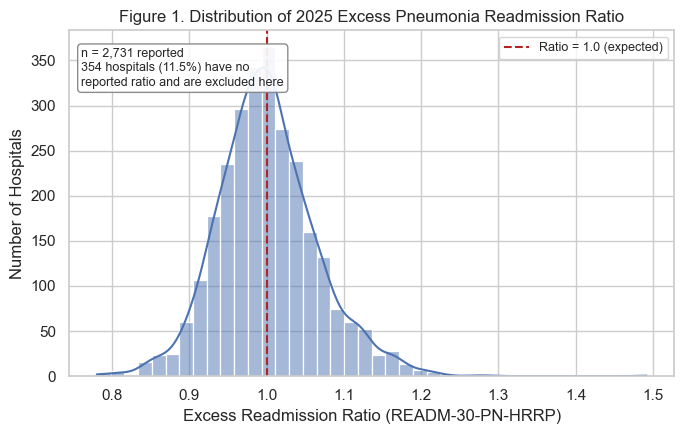

In [13]:
# Figure 1. Target distribution
fig, ax = plt.subplots(figsize=(7, 4.5))
valid = df[TARGET].dropna()
n_missing = df[TARGET].isna().sum()
sns.histplot(valid, bins=40, kde=True, ax=ax, color="#4C72B0")
ax.axvline(1.0, color="firebrick", linestyle="--", linewidth=1.5, label="Ratio = 1.0 (expected)")
ax.set_title("Figure 1. Distribution of 2025 Excess Pneumonia Readmission Ratio")
ax.set_xlabel("Excess Readmission Ratio (READM-30-PN-HRRP)")
ax.set_ylabel("Number of Hospitals")
ax.text(0.02, 0.95, f"n = {len(valid):,} reported\n{n_missing} hospitals (11.5%) have no\nreported ratio and are excluded here",
        transform=ax.transAxes, va="top", fontsize=9, bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9))
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

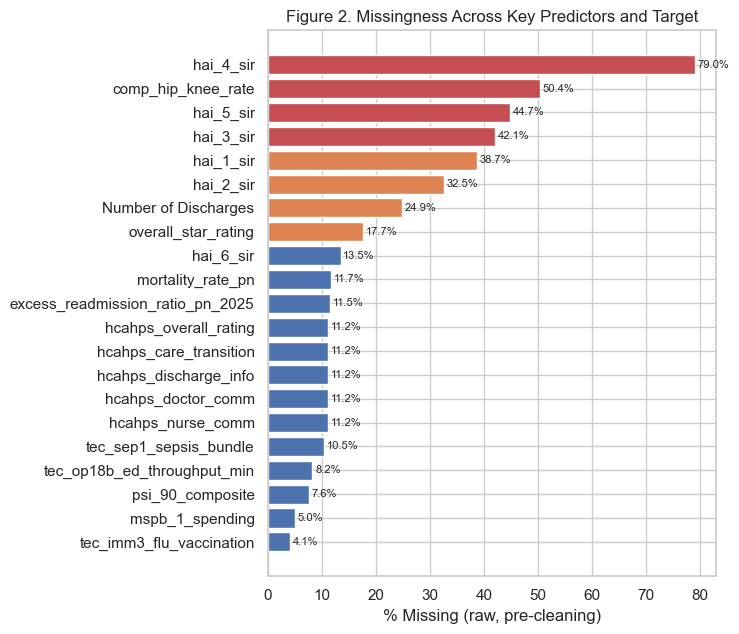

In [14]:
# Figure 2. Missingness across key predictors and target
pct_missing = (df[CONTINUOUS].isna().mean() * 100).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
colors = ["#C44E52" if v > 40 else "#DD8452" if v > 15 else "#4C72B0" for v in pct_missing.values]
ax.barh(pct_missing.index, pct_missing.values, color=colors)
ax.set_xlabel("% Missing (raw, pre-cleaning)")
ax.set_title("Figure 2. Missingness Across Key Predictors and Target")
for i, v in enumerate(pct_missing.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)
fig.tight_layout()
plt.show()

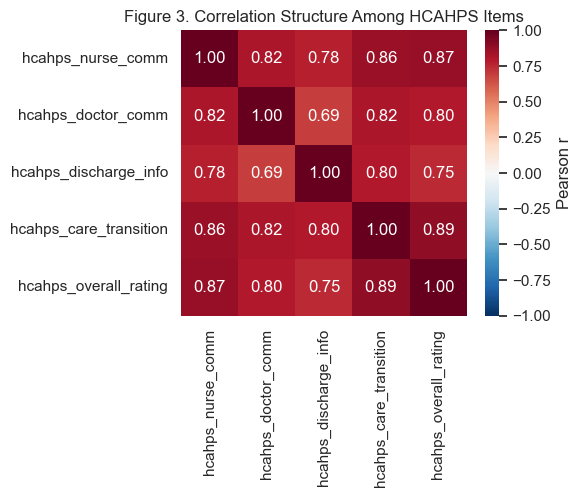

In [15]:
# Figure 3. HCAHPS correlation structure
hcahps_cols = ["hcahps_nurse_comm", "hcahps_doctor_comm", "hcahps_discharge_info", "hcahps_care_transition", "hcahps_overall_rating"]
corr3 = df[hcahps_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr3, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Figure 3. Correlation Structure Among HCAHPS Items")
fig.tight_layout()
plt.show()

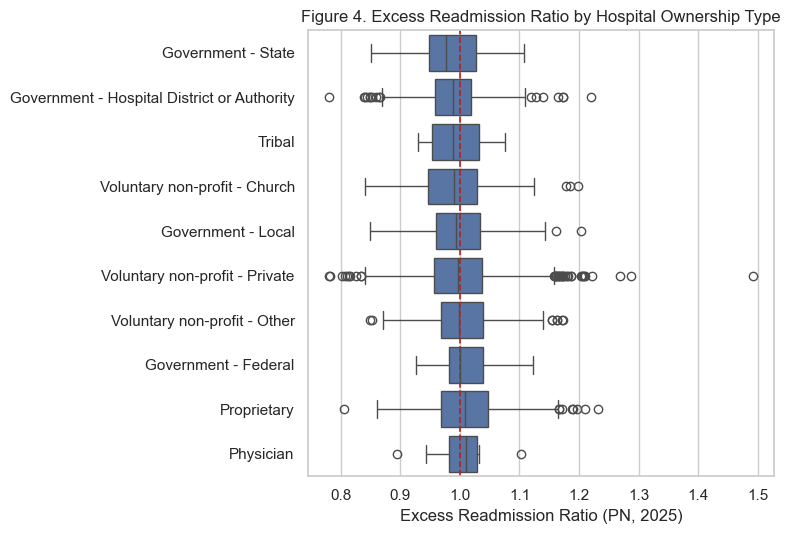

In [16]:
# Figure 4. Target by hospital ownership type
order = df.groupby("ownership_type")[TARGET].median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(data=df, y="ownership_type", x=TARGET, order=order, ax=ax, color="#4C72B0")
ax.axvline(1.0, color="firebrick", linestyle="--", linewidth=1.2)
ax.set_title("Figure 4. Excess Readmission Ratio by Hospital Ownership Type")
ax.set_xlabel("Excess Readmission Ratio (PN, 2025)")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

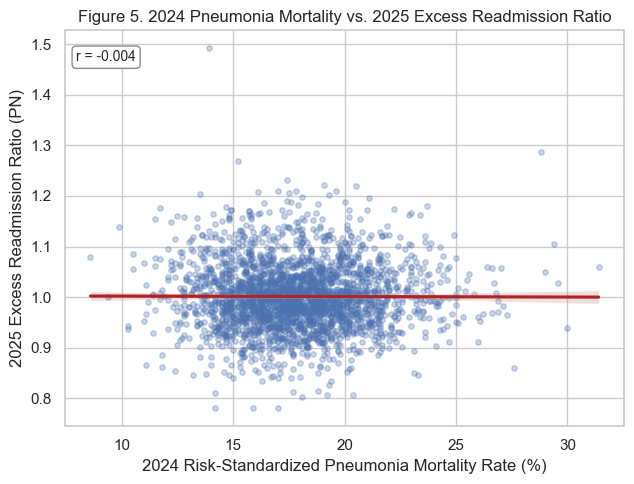

In [17]:
# Figure 5. 2024 pneumonia mortality vs. 2025 excess readmission ratio
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.regplot(data=df, x="mortality_rate_pn", y=TARGET, ax=ax, scatter_kws={"alpha": 0.3, "s": 15}, line_kws={"color": "firebrick"})
r5 = df[["mortality_rate_pn", TARGET]].corr().iloc[0, 1]
ax.set_title("Figure 5. 2024 Pneumonia Mortality vs. 2025 Excess Readmission Ratio")
ax.set_xlabel("2024 Risk-Standardized Pneumonia Mortality Rate (%)")
ax.set_ylabel("2025 Excess Readmission Ratio (PN)")
ax.text(0.02, 0.95, f"r = {r5:.3f}", transform=ax.transAxes, va="top", fontsize=10, bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9))
fig.tight_layout()
plt.show()

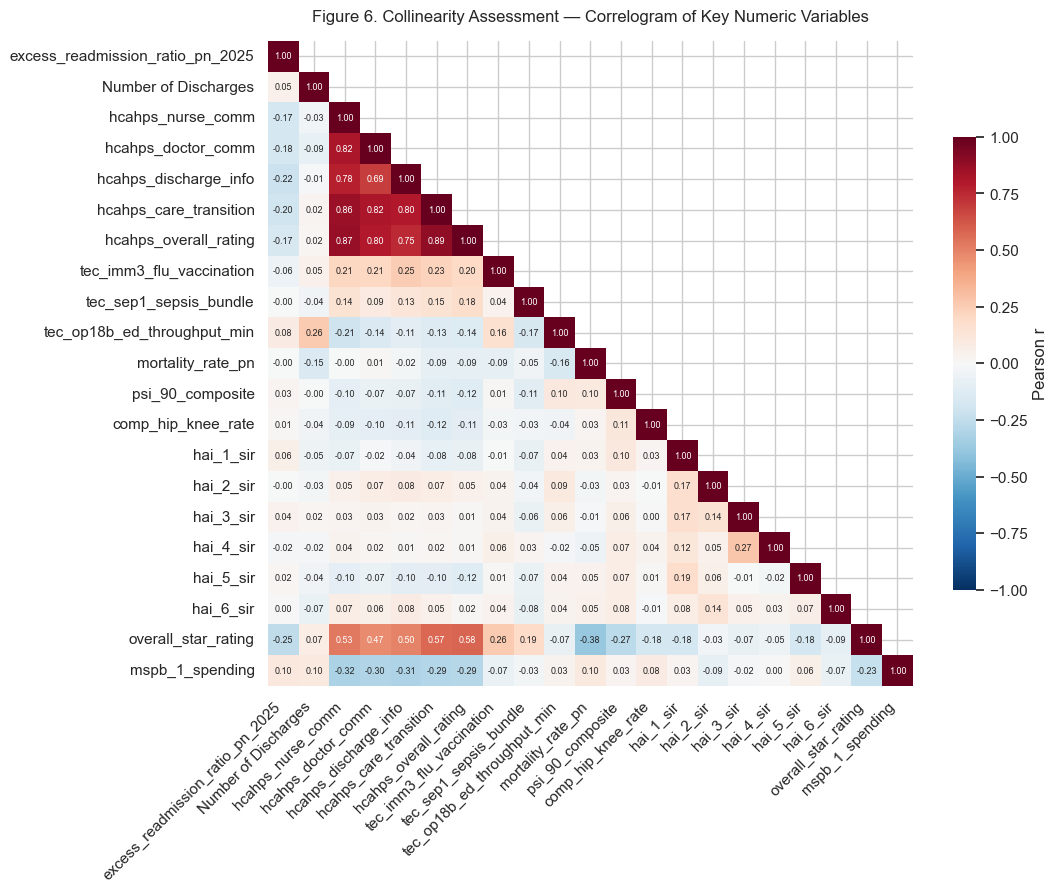

In [18]:
# Figure 6. Full correlogram (collinearity assessment)
corr_cols = [TARGET, "Number of Discharges", *hcahps_cols,
             "tec_imm3_flu_vaccination", "tec_sep1_sepsis_bundle", "tec_op18b_ed_throughput_min",
             "mortality_rate_pn", "psi_90_composite", "comp_hip_knee_rate",
             "hai_1_sir", "hai_2_sir", "hai_3_sir", "hai_4_sir", "hai_5_sir", "hai_6_sir",
             "overall_star_rating", "mspb_1_spending"]
corr6 = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr6, dtype=bool), k=1)
sns.heatmap(corr6, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True,
            ax=ax, annot_kws={"size": 6.5}, cbar_kws={"label": "Pearson r", "shrink": 0.7})
ax.set_title("Figure 6. Collinearity Assessment — Correlogram of Key Numeric Variables", pad=14)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
plt.show()

## 4. Key correlations referenced in the report



In [19]:
print("Correlation with target:")
for col in ["mortality_rate_pn", "hcahps_overall_rating", "overall_star_rating", "mspb_1_spending", "psi_90_composite"]:
    print(f"  {col}: r = {df[[col, TARGET]].corr().iloc[0,1]:.3f}")

Correlation with target:
  mortality_rate_pn: r = -0.004
  hcahps_overall_rating: r = -0.167
  overall_star_rating: r = -0.253
  mspb_1_spending: r = 0.103
  psi_90_composite: r = 0.031


## Notes for next steps

- 354 hospitals (11.5%) have no reported 2025 pneumonia ratio and must be **excluded**, not imputed, from any model.
- `hospital_type` is 99.8% one category — a strong drop candidate before modeling.
- The five HCAHPS items are highly intercorrelated (Figure 3) — handle with elastic-net/tree models rather than plain OLS, or expect an explicit VIF/pruning discussion.
- `mortality_rate_pn` shows ~zero linear correlation with the target — worth a non-linear check before concluding it carries no signal.
- See `docs/eda_report/EDA_Report.docx` for the full narrative write-up this notebook supports.
